<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/SFDS/egg_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Royal Draconic Conservatory**

<div style="text-align: center;">
   <img src="https://raw.githubusercontent.com/kwanda2426/projects/main/SFDS/egg.png"  width="800">
</div>




# **Importing Libraries**

In [1]:
!pip -q install plotly scikit-learn tabulate pandas --upgrade xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 54.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.


In [2]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px
from scipy.stats import kurtosis


#Feature engineering, selection and Model training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate
from IPython.display import display


# **Data acquisition**

#### Main Data

In [3]:
# Loading Data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/SFDS/egg_data.csv"
df = pd.read_csv(url)
df.head()

,SPEC,VOL,MASS,AGE,SPOT,NEST,TEMP,SPC
0,Wyvern,398,665,446,10,Coastal,38.7,Wyvern
1,Hydra,13,7,477,8,Volcanic,82.9,Hydra
2,Hydra,61,32,74,8,Coastal,29.0,Hydra
3,Hydra,44,68,207,9,Forest,21.8,Hydra
4,Dragon,99,120,61,2,Volcanic,70.9,Dragon


In [4]:
# Create the data as a list of dictionaries
variables = [

    {"variable": "MASS", "description": "Mass of the egg (kg)."},
    {"variable": "VOL", "description": "Volume of the egg (litres)."},
    {"variable": "AGE", "description": "Age of the egg (days since laying)."},
    {"variable": "NEXT", "description": "Type of nest (categorical; Volcanic, Forest, Mountain, Coastal or Swamp)."},
    {"variable": "SPOT", "description": "Number of visible shell spots"},
    {"variable": "TEMP", "description": " Surface Temprature of the egg in centigrade."},
    {"variable": "SPEC", "description": " Target variable (Dragon, Wyvern, Hydra)."},


]


# Display the DataFrame
var_desc = pd.DataFrame(variables)
var_desc_final = var_desc.reset_index(drop = True)

# Display the DataFrame
print(tabulate(var_desc_final, headers = 'keys', tablefmt = 'grid'))

+----+------------+---------------------------------------------------------------------------+
|    | variable   | description                                                               |
+====+============+===========================================================================+
|  0 | MASS       | Mass of the egg (kg).                                                     |
+----+------------+---------------------------------------------------------------------------+
|  1 | VOL        | Volume of the egg (litres).                                               |
+----+------------+---------------------------------------------------------------------------+
|  2 | AGE        | Age of the egg (days since laying).                                       |
+----+------------+---------------------------------------------------------------------------+
|  3 | NEXT       | Type of nest (categorical; Volcanic, Forest, Mountain, Coastal or Swamp). |
+----+------------+---------------------

# **Data Exploratory Analysis**

Data preprocessing is vital because it transforms messy raw data into a clean, consistent, and structured format, which is essential for accurate analysis and effective machine learning models.
Issues like missing values, inconsistencies, errors, and outliers are addressed to improve data quality,leads to more reliable and meaningful insights for decision-making and ultimately enhances the performance and accuracy of models.



In [5]:
df_main = df.copy()

#### Reviewing and Renaming Columns


In [6]:
# data columns
df_main.columns

Index(['SPEC', 'VOL', 'MASS', 'AGE', 'SPOT', 'NEST', 'TEMP', 'SPC'], dtype='str')

- There are column names that have UPPERCASE. All variable names are converted to lowercase.

In [7]:
# Changing column names
df_main.columns = df_main.columns.str.replace(' ', '_', regex=False).str.lower()
df_main.head()

,spec,vol,mass,age,spot,nest,temp,spc
0,Wyvern,398,665,446,10,Coastal,38.7,Wyvern
1,Hydra,13,7,477,8,Volcanic,82.9,Hydra
2,Hydra,61,32,74,8,Coastal,29.0,Hydra
3,Hydra,44,68,207,9,Forest,21.8,Hydra
4,Dragon,99,120,61,2,Volcanic,70.9,Dragon


#### Dataset Dimensions and Variable Type

In [8]:
df = df_main.copy()

In [9]:
# Rows and Columns of data
print('Data has {} rows and {} Columns'.format(df.shape[0],df.shape[1]))
print('')
print('Data has the following variables with missing values:')
print('')
major_missing = []
for i in df_main.columns:
  missing_values = 100*df_main[i].isnull().sum()/df_main.shape[0]
  print(i+', with {}% of missing data'.format(missing_values))


Data has 500 rows and 8 Columns

Data has the following variables with missing values:

spec, with 0.0% of missing data
vol, with 0.0% of missing data
mass, with 0.0% of missing data
age, with 0.0% of missing data
spot, with 0.0% of missing data
nest, with 0.0% of missing data
temp, with 0.0% of missing data
spc, with 0.0% of missing data


- No missing data.

#### SPEC - Target Variable Distribution

<Axes: >

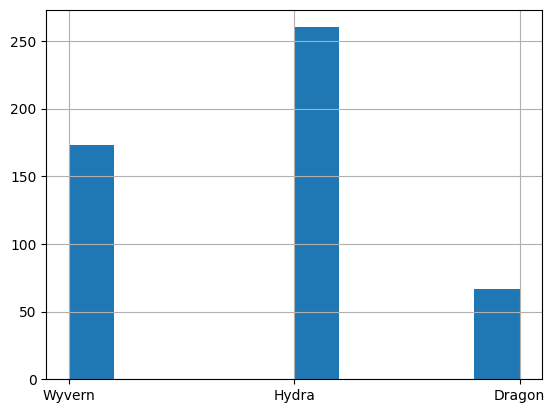

In [10]:
df_main.spec.hist()

In [11]:
# Number of observations
df_main.spec.value_counts()

spec
Hydra     260
Wyvern    173
Dragon     67
Name: count, dtype: int64

**Observations**
- Hydra is the dominant class
Over half of the dataset belongs to Hydra.
This suggests the dataset is biased toward Hydra observations.
- Dragon is underrepresented compared to Wyvern and Hydra.

This could create a class imbalance problem in modelling implying that the model may learn Hydra and Wyvern  patterns better than Dragon patterns.
Metrics like accuracy alone may become misleading. Hence stratification is needed when splitting train/test data.

 #### NEST-  Type of nest Distribution

<Axes: >

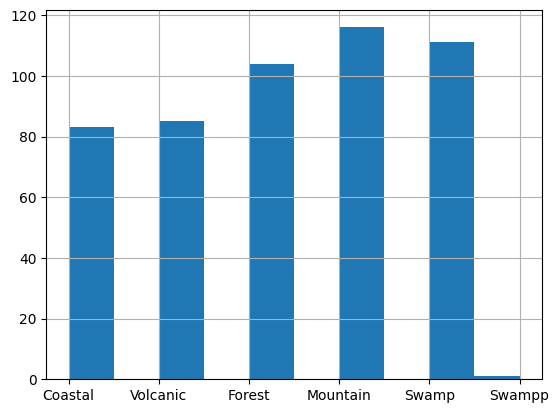

In [12]:
df_main.nest.hist()

In [13]:
# Number of observations
df_main.nest.value_counts()

nest
Mountain    116
Swamp       111
Forest      104
Volcanic     85
Coastal      83
Swampp        1
Name: count, dtype: int64

**Observations**
- There's an issue with Swampp - it is a data issue which was supposed to be Swampp. This can be dropped because it is one datapoint.
- The counts across Mountain, Swamp, Forest, Volcanic, and Coastal nests are relatively close, meaning no single category heavily dominates the dataset.
- Mountain nests are the most common while Coastal nests are the least common
Mountain has the highest number of observations (116), whereas Coastal has the lowest (83), noting that the difference is not extreme.
- The feature is suitable for machine learning models
Because the categories are reasonably balanced, the feature can provide useful predictive information without causing major class imbalance issues.

#### Summary Statistics

In [14]:
#describing numerical columns
df_main.describe().T

,count,mean,std,min,25%,50%,75%,max
vol,500.0,92.1920,153.385623,0.0,11.00,37.5,99.25,1299.0
mass,500.0,173.7380,512.251904,-132.0,7.00,31.0,110.25,5162.0
age,500.0,250.5240,144.517639,0.0,133.00,247.5,380.00,500.0
spot,500.0,6.4640,5.260423,0.0,2.00,5.0,9.00,20.0
temp,500.0,40.7854,20.144801,6.3,27.75,35.4,44.50,95.9


**Observations**:

- Both vol and mass appear heavily right-skewed. The means are far above the medians, which usually indicates potential outliers. This means that the data might need to be transformed or create a new feature from the two.

- mass has a negative minimum value. This is strange because a physical mass should not be negative. This might be because of calibration errors or data corruption. These data points can be removed or treated as anomalies.

- age looks uniformly distributed.

- spot behave like categorical features. it can be beneficial to bin these values.

- temp behave normal compared to the other features.

In [15]:
# negative mass
df_main[df_main['mass'] < 0].shape

(1, 8)

The negative mass issue looks like a single data point. This can be removed.

#### Feature Distribution

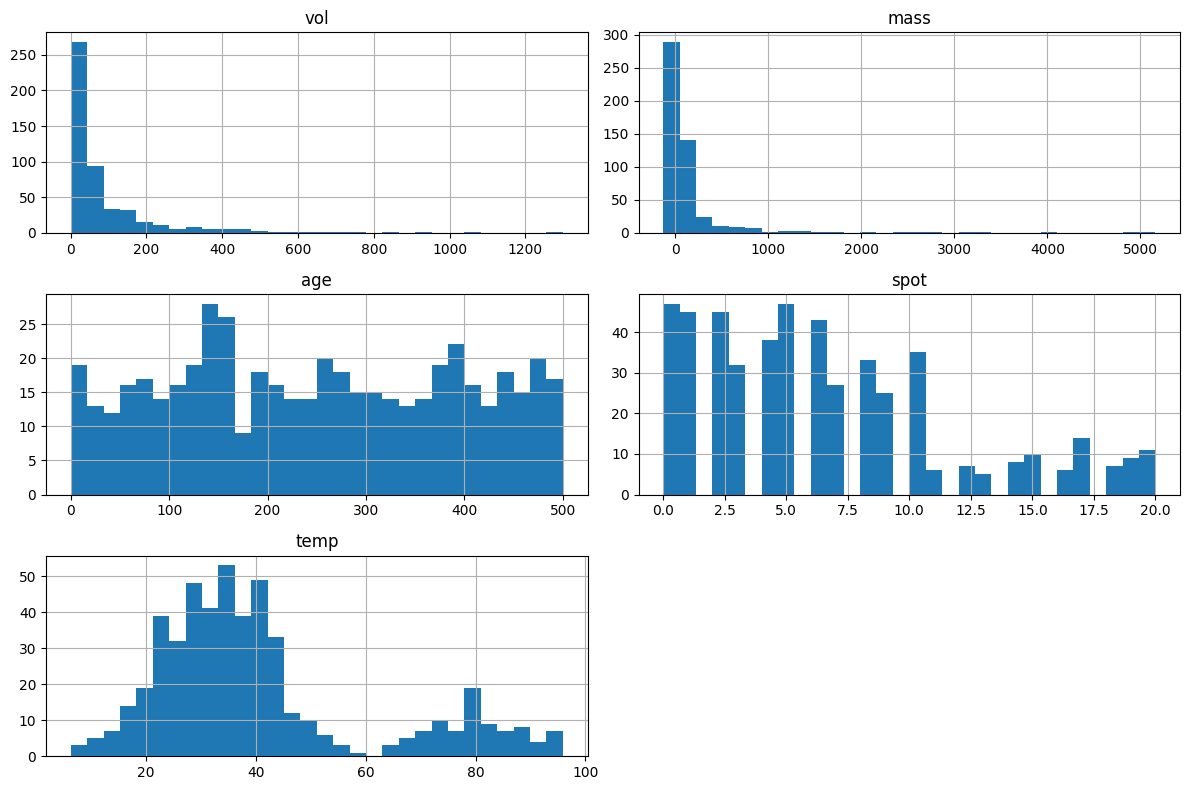

In [16]:
# Building histograms
df = df_main.copy()
df.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

- This confirms what is shown by the summary statistics.

# **Feature Selection and Engineering**

This is a vital step - Feature transformation improves model performance by making data easier to learn from, especially when features have different scales or distributions. Scaling prevents features with larger numerical values from disproportionately influencing the model's learning. When features have vastly different ranges (e.g., one feature ranges from 0-10 and another from 0-10,000), the model can become biased toward the feature with the larger magnitude, simply because its values are larger. Binning and other transformations help reduce skewness, limit the impact of outliers, and capture non-linear relationships.

In [17]:
# creating copy of dataset
df_semi = df_main.copy()

# data points excluding negative mass
df_semi = df_semi[df_semi['mass'] > 0]

# Remove data point of Swampp
df_semi = df_semi[df_semi['nest'] !=  'Swampp']

- This deals with the skewness of these two features.

In [18]:
# initialise encoder
le = LabelEncoder()

# Encoding Nest feature
df_semi = pd.get_dummies(df_semi, columns = ['nest'])

# Encoding target variable
df_semi['spec'] = le.fit_transform(df_semi['spec'])

- LabelEncoder() provides a simple, consistent, and lossless way to convert variables to numeric because most machine learning algorithms can only work with numbers, not text or categories.

In [19]:
# initialise scaler
scaler = StandardScaler()

# scale age using standard scaler
df_semi['age'] = scaler.fit_transform(df_semi[['age']])

# scale age using standard scaler
df_semi['temp'] = scaler.fit_transform(df_semi[['temp']])

- StandardScaler standardize numeric features so they have mean 0 and variance 1, ensuring all features contribute equally and improving model performance.

In [20]:
df_semi.head()

,spec,vol,mass,age,spot,temp,spc,nest_Coastal,nest_Forest,nest_Mountain,nest_Swamp,nest_Volcanic
0,2,398,665,1.348756,10,-0.098936,Wyvern,True,False,False,False,False
1,1,13,7,1.564454,8,2.102293,Hydra,False,False,False,False,True
2,1,61,32,-1.239619,8,-0.582011,Hydra,True,False,False,False,False
3,1,44,68,-0.314205,9,-0.940582,Hydra,False,True,False,False,False
4,0,99,120,-1.330073,2,1.504674,Dragon,False,False,False,False,True


In [21]:
df_semi.columns

Index(['spec', 'vol', 'mass', 'age', 'spot', 'temp', 'spc', 'nest_Coastal',
       'nest_Forest', 'nest_Mountain', 'nest_Swamp', 'nest_Volcanic'],
      dtype='str')

In [22]:
df_final = df_semi.copy()
df_final.head()

,spec,vol,mass,age,spot,temp,spc,nest_Coastal,nest_Forest,nest_Mountain,nest_Swamp,nest_Volcanic
0,2,398,665,1.348756,10,-0.098936,Wyvern,True,False,False,False,False
1,1,13,7,1.564454,8,2.102293,Hydra,False,False,False,False,True
2,1,61,32,-1.239619,8,-0.582011,Hydra,True,False,False,False,False
3,1,44,68,-0.314205,9,-0.940582,Hydra,False,True,False,False,False
4,0,99,120,-1.330073,2,1.504674,Dragon,False,False,False,False,True


In [23]:
df_final.spec.value_counts()

spec
1    243
2    166
0     61
Name: count, dtype: int64

In [24]:
df_main.spec.value_counts()

spec
Hydra     260
Wyvern    173
Dragon     67
Name: count, dtype: int64

#### Data Split
Splitting data into training and testing sets is essential to evaluate a model's performance on new, unseen data and prevent overfitting. The training set teaches the model patterns, while the untouched test set provides an unbiased assessment of its generalisation ability, ensuring the model performs accurately in real-world scenarios rather than just on the data it learned from.


In [25]:
# features and target variable
X = df_final.drop(['spec','spc'], axis = 1)
y = df_final['spec']

In [26]:
# Split into train+val and test (80/20)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split train+val into train and validation (75/25 of trainval = 60/20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

# **Model Construction**

In this step, data is training data fed to the model. Training a model is essential because it allows the algorithm to learn patterns and relationships from data so it can make accurate predictions or decisions on new, unseen inputs. Without training, the model would have no understanding of how features relate to outcomes.

- XGBoost is used because it is a powerful, efficient, and scalable gradient boosting algorithm that handles non-linear relationships, interactions between features, and missing values automatically, often achieving high predictive accuracy with relatively little tuning.


In [27]:
num_classes = y_train.nunique()

model = xgb.XGBClassifier(
    objective='multi:softprob',  # multi-class classification
    eval_metric='mlogloss',      # multi-class log loss
    num_class=num_classes,
    use_label_encoder=False,
    random_state=42
)

In [28]:
model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose =  False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

- Logistic  - Multinomial logistic regression predicts the probability that an observation belongs to each class and assigns the observation to the class with the highest probability. The model was appropriate because it is computationally efficient, interpretable, and performs well for categorical classification tasks.

In [29]:
# Build the model
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

In [30]:
# Train model
log_reg.fit(X_train, y_train)

# Validation predictions
y_val_pred = log_reg.predict(X_val)

In [31]:
# Validation evaluation
print("Validation Accuracy:")
print(accuracy_score(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Validation Accuracy:
0.8085106382978723

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80        12
           1       0.80      0.88      0.83        49
           2       0.78      0.76      0.77        33

    accuracy                           0.81        94
   macro avg       0.86      0.77      0.80        94
weighted avg       0.82      0.81      0.81        94


Confusion Matrix:
[[ 8  3  1]
 [ 0 43  6]
 [ 0  8 25]]


# **Model Evaluation**

Models are evaluated using the validation dataset. Validating these trained models is crucial because it helps identify which one performs best to unseen data—without touching the test set. This step acts like a rehearsal before the final performance: it reveals whether the model is overfitting (memorising the training data) or underfitting (failing to learn enough). By evaluating on the validation set, we can select the most promising model and fine-tune its hyperparameters, ensuring that when it is finally tested, the true predictive power is measured — not just luck or overtraining.

#####XGBoost

In [32]:
# Predict on the test set
y_pred = model.predict(X_test)

# Classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.67      0.57        12
           1       0.75      0.78      0.76        49
           2       0.74      0.61      0.67        33

    accuracy                           0.70        94
   macro avg       0.66      0.68      0.67        94
weighted avg       0.71      0.70      0.70        94



In [33]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 8  3  1]
 [ 5 38  6]
 [ 3 10 20]]


###Logistic Regression

In [34]:
# Test predictions
y_test_pred = log_reg.predict(X_test)

# Test evaluation
print("\nTest Accuracy:")
print(accuracy_score(y_test, y_test_pred))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Test Accuracy:
0.7021276595744681

Test Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57        12
           1       0.74      0.80      0.76        49
           2       0.66      0.64      0.65        33

    accuracy                           0.70        94
   macro avg       0.69      0.64      0.66        94
weighted avg       0.70      0.70      0.70        94


Test Confusion Matrix:
[[ 6  4  2]
 [ 1 39  9]
 [ 2 10 21]]


# **Interpretation**



Both XGBoost and Logistic Regression achieved identical overall accuracy of 70%. However, XGBoost showed slightly better macro-average F1-score, indicating improved balanced performance across classes. In particular, XGBoost demonstrated higher recall for the minority class, suggesting better ability to identify underrepresented cases. Logistic Regression performed comparably on the majority class but showed slightly weaker balance across minority classes. Overall, XGBoost provides a marginal improvement in class-balanced performance, while Logistic Regression remains a strong and interpretable baseline model.